<a href="https://colab.research.google.com/github/nazianusrat/Screentime-Reduction-what-works-vs-what-fails/blob/main/figure2_revised_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


- **Panel A** — categories with an explicit Cohen's d / SMD stated in the thesis.
- **Panel B** — categories reported only in % or minutes/day (clearly labeled by unit).

### Data table
| Category | Value | Metric | Source (as cited in thesis) |
|---|---|---|---|
| School-based (problematic use) | 1.47 | Cohen's d | Žmavc et al., 2025 |
| Self-monitoring (tracking+goal) | 0.811 | Cohen's d | Li et al., 2025 |
| School-based (screen time, meta-analysis) | 0.26 | SMD | Wu et al., 2025b |
| Child/adolescent behavioral interventions (meta-analysis) | 0.116 | SMD | Jones et al., 2021 |
| Internet blocking | ~50% reduction | % | Castelo et al., 2025 |
| Grayscale mode | 38 min/day | minutes | Holte & Ferraro, 2020 |
| Family counseling (infants) | 53%→3% gap | pct-point | Poonia et al., 2024 |
| PLUMS family program | 28 min/day | minutes | Kaur et al., 2024 |
| Facebook deactivation | 22% reduction | % | Allcott et al., 2020 |
| MindShift AI nudge | 7.4–9.8% (midpoint 8.6%) | % | Wu et al., 2024 |
| Time2Stop AI timing | 7.0–8.9% (midpoint 8.0%) | % | Orzikulova et al., 2024 |
| MyTime goal-setting | 21% (targeted apps only) | % | Hiniker et al., 2016 |


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

os.makedirs('output', exist_ok=True)

In [18]:
# PANEL A: categories with a genuine Cohen's d / SMD
panel_a = [
    ("School-based\n(problematic use)\nŽmavc et al. 2025", 1.47, "d"),
    ("Self-monitoring\n(tracking+goal)\nLi et al. 2025", 0.811, "d"),
    ("School-based\n(screen time, meta)\nWu et al. 2025b", 0.26, "SMD"),
    ("Child/adolescent\nbehavioral (meta)\nJones et al. 2021", 0.116, "SMD"),
]

# PANEL B: categories reported only in % or minutes/day reduction (NOT a d-value)
panel_b = [
    ("Internet blocking\n(Castelo et al. 2025)", 50, "% reduction (~halved)"),
    ("Grayscale mode\n(Holte & Ferraro 2020)", 38, "min/day reduction"),
    ("Family counseling, infants\n(Poonia et al. 2024)", 50, "pct-point gap (53%->3%)"),
    ("PLUMS family program\n(Kaur et al. 2024)", 28, "min/day reduction"),
    ("Facebook deactivation\n(Allcott et al. 2020)", 22, "% reduction, persists 9wks"),
    ("MindShift AI nudge\n(Wu et al. 2024)", 8.6, "% reduction (7.4-9.8 range, midpt)"),
    ("Time2Stop AI timing\n(Orzikulova et al. 2024)", 8.0, "% reduction (7.0-8.9 range, midpt)"),
    ("MyTime goal-setting\n(Hiniker et al. 2016)", 21, "% reduction (targeted apps)"),
]

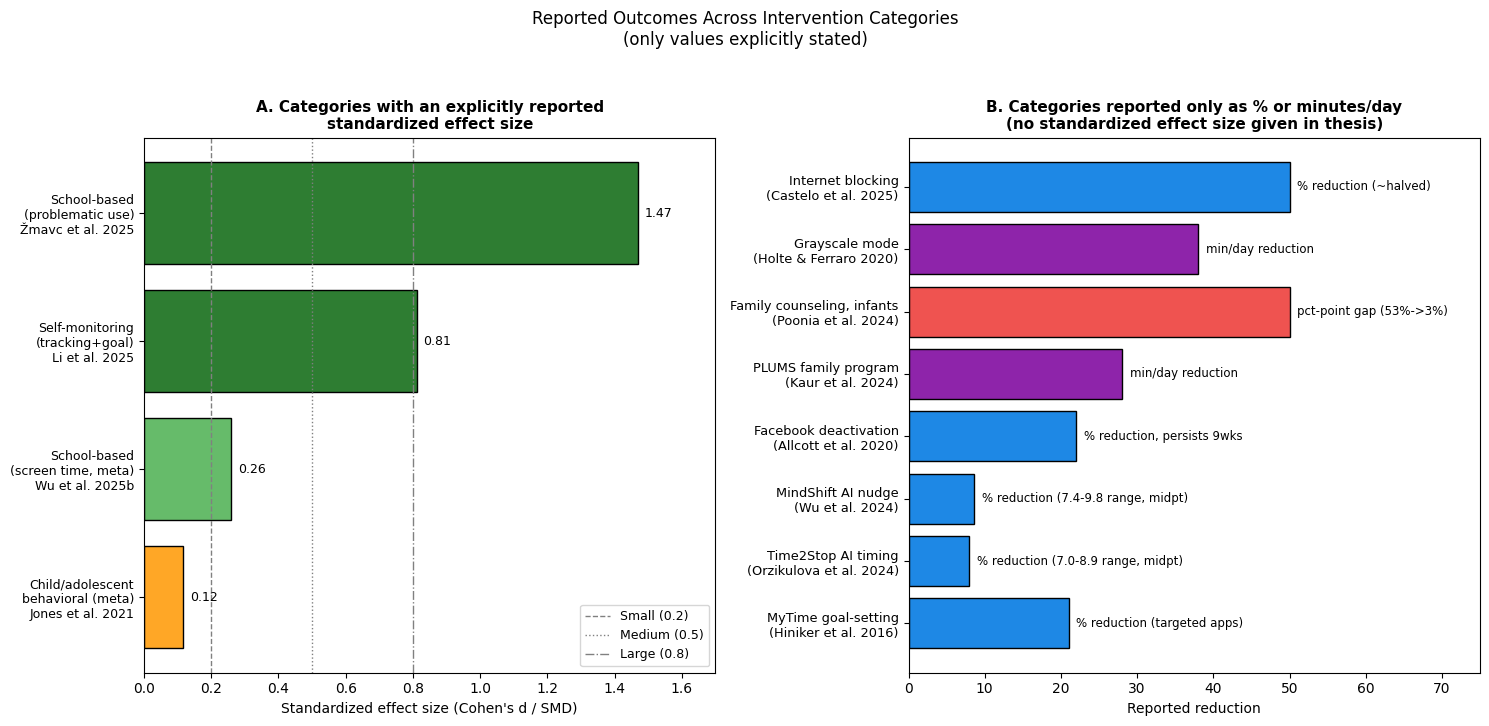

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ---- Panel A ----
labels_a = [x[0] for x in panel_a]
values_a = [x[1] for x in panel_a]
colors_a = ['#2E7D32' if v >= 0.5 else '#66BB6A' if v>=0.2 else '#FFA726' for v in values_a]

y_pos = np.arange(len(labels_a))
axes[0].barh(y_pos, values_a, color=colors_a, edgecolor='black')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(labels_a, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("Standardized effect size (Cohen's d / SMD)", fontsize=10)
axes[0].set_title("A. Categories with an explicitly reported\nstandardized effect size", fontsize=11, fontweight='bold')
axes[0].axvline(0.2, color='gray', linestyle='--', linewidth=1, label='Small (0.2)')
axes[0].axvline(0.5, color='gray', linestyle=':', linewidth=1, label='Medium (0.5)')
axes[0].axvline(0.8, color='gray', linestyle='-.', linewidth=1, label='Large (0.8)')
for i, v in enumerate(values_a):
    axes[0].text(v + 0.02, i, f"{v:.2f}", va='center', fontsize=9)
axes[0].legend(fontsize=9, loc='lower right')
axes[0].set_xlim(0, 1.7)

# ---- Panel B ----
labels_b = [x[0] for x in panel_b]
values_b = [x[1] for x in panel_b]
units_b  = [x[2] for x in panel_b]

bar_colors = []
for u in units_b:
    if 'min/day' in u: bar_colors.append('#8E24AA')
    elif 'pct-point' in u: bar_colors.append('#EF5350')
    else: bar_colors.append('#1E88E5')

y_pos_b = np.arange(len(labels_b))
axes[1].barh(y_pos_b, values_b, color=bar_colors, edgecolor='black')
axes[1].set_yticks(y_pos_b)
axes[1].set_yticklabels(labels_b, fontsize=9.3)
axes[1].invert_yaxis()
axes[1].set_xlabel("Reported reduction", fontsize=10)
axes[1].set_title("B. Categories reported only as % or minutes/day\n(no standardized effect size given in thesis)", fontsize=11, fontweight='bold')
for i, (v, u) in enumerate(zip(values_b, units_b)):
    axes[1].text(v + 1, i, u, va='center', fontsize=8.5)
axes[1].set_xlim(0, 75)

plt.suptitle("Reported Outcomes Across Intervention Categories\n(only values explicitly stated)",
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig("output/figure2_revised.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
from google.colab import files
files.download('output/figure2_revised.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>